In [1]:
# ========================
# 1. IMPORT LIBRARIES
# ========================
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ========================
# 2. LOAD DATA
# ========================
data=pd.read_csv('netflix_titles.csv')
print("Shape: ",data.shape)
# data.head()
# data.info()
print(data.columns.tolist())



Shape:  (8807, 12)
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [3]:
# ========================
# 3. CLEAN DATA
# ========================

#Check duplicate
print(len(data['title'].unique())==data.shape[0])

#Drop những hàng quan trọng (thiếu data quan trọng để phân tích)
data=data.dropna(subset=['date_added','rating','duration'])

#Drop những cột không cần
data=data.drop(columns=['director','cast'])

#Fill những cột bị missing
data['country']=data['country'].fillna('Unknown')


#Convert datatype
data['date_added'] = pd.to_datetime(data['date_added'].str.strip())




True


In [4]:
# ========================
# 4. ANALYSIS
# ========================

#tạo thêm cột year_added
data['year_added']=data['date_added'].dt.year
data=data.sort_values(by='year_added',ascending=True)

#Lọc các thể loại trên netflix
movie=data[data['type']=='Movie'].copy()
tvshow=data[data['type']=='TV Show'].copy()

#Tỷ lệ Movie, TV show trên Netflix
print("Movie rating: ",len(movie)/len(data))
print("TV Show rating: ",len(tvshow)/len(data))

#Thời lượng trung bình của Movie
movie['duration'] = movie['duration'].str.extract('(\d+)').astype(float)
print("AVG Movie's duration: ",movie['duration'].mean())

#Số mùa trung bình của TV show
tvshow['duration'] = tvshow['duration'].str.extract('(\d+)').astype(float)
print("AVG TVshow's duration: ",tvshow['duration'].mean())

Movie rating:  0.6969283276450512
TV Show rating:  0.3030716723549488
AVG Movie's duration:  99.58488410055502
AVG TVshow's duration:  1.7518768768768769


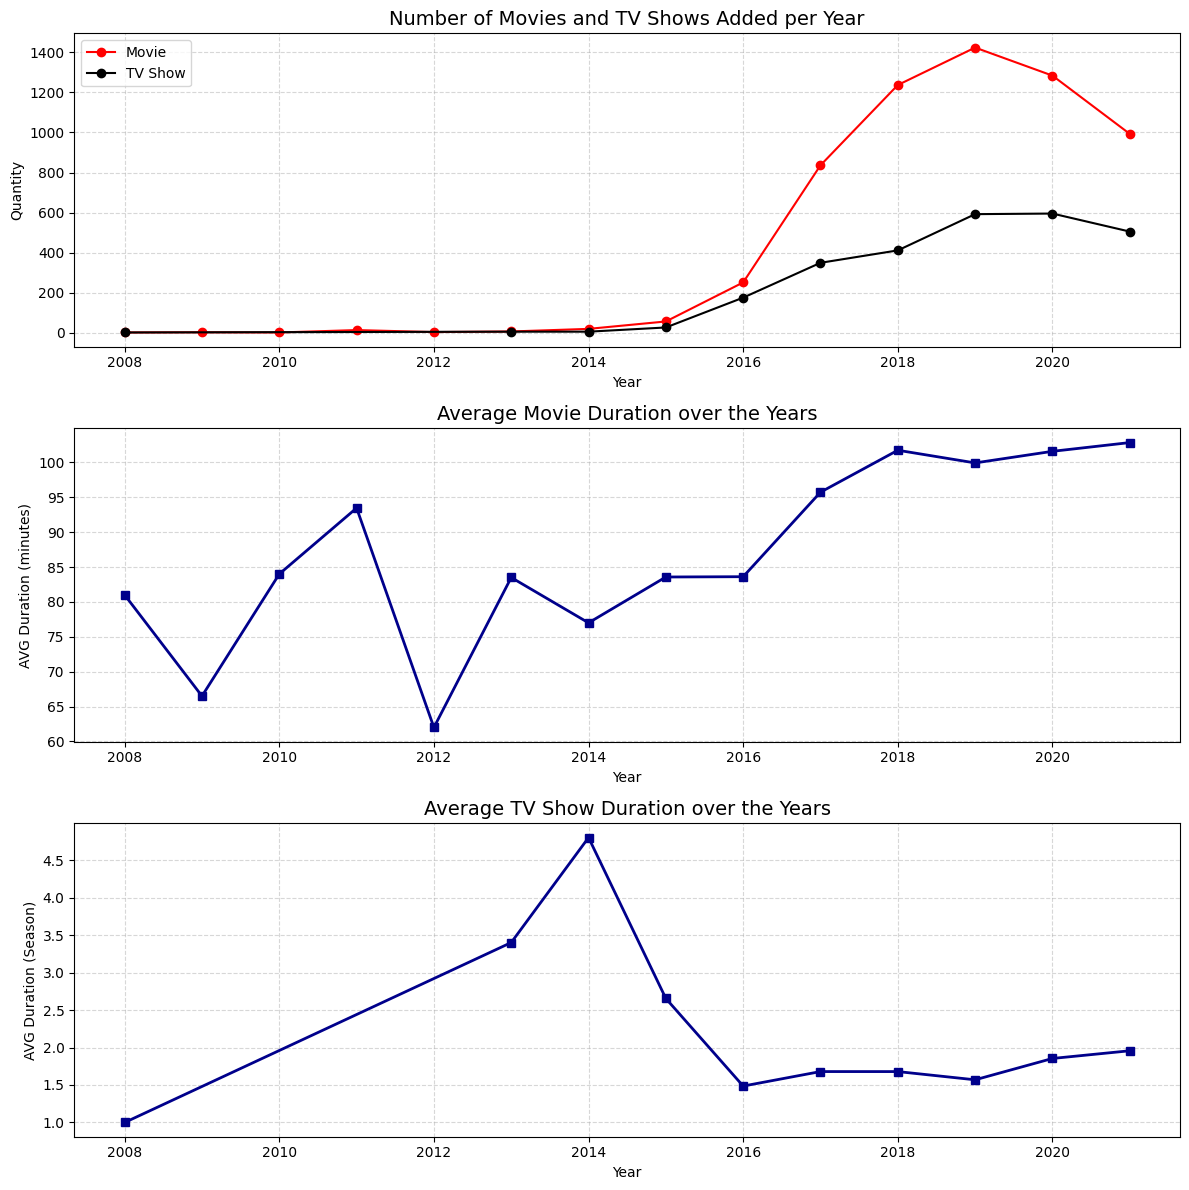

In [5]:
# ========================
# 5. VISUALIZATION
# ========================


avg_duration_per_year1=tvshow.groupby('year_added')['duration'].mean()
avg_duration_per_year=movie.groupby('year_added')['duration'].mean()
movie_per_year=movie.groupby('year_added').size()
tvshow_per_year=tvshow.groupby('year_added').size()
fig, (ax1, ax2,ax3) = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))

# --- BIỂU ĐỒ 1: SỐ LƯỢNG MOVIE VÀ TV SHOW QUA CÁC NĂM ---
ax1.plot(movie_per_year.index, movie_per_year.values, label='Movie', color='red', marker='o')
ax1.plot(tvshow_per_year.index, tvshow_per_year.values, label='TV Show', color='black', marker='o')
ax1.set_title('Number of Movies and TV Shows Added per Year', fontsize=14)
ax1.set_xlabel('Year')
ax1.set_ylabel('Quantity')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: THỜI LƯỢNG TRUNG BÌNH CỦA MỖI MOVIE ---
ax2.plot(avg_duration_per_year.index, avg_duration_per_year.values, 
         color='darkblue', marker='s', linestyle='-', linewidth=2)
ax2.set_title('Average Movie Duration over the Years', fontsize=14)
ax2.set_xlabel('Year')
ax2.set_ylabel('AVG Duration (minutes)')
ax2.grid(True, linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 3: THỜI LƯỢNG TRUNG BÌNH CỦA TV SHOW ---
ax3.plot(avg_duration_per_year1.index, avg_duration_per_year1.values, 
         color='darkblue', marker='s', linestyle='-', linewidth=2)
ax3.set_title('Average TV Show Duration over the Years', fontsize=14)
ax3.set_xlabel('Year')
ax3.set_ylabel('AVG Duration (Season)')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
# ========================
# 6. INSIGHT
# ========================
print("""
- Movie chiếm phần lớn nội dung trên Netflix (~70%)
- Giai đoạn 2016–2019 là thời kỳ bùng nổ của Movie
- TV Show tăng trưởng chậm hơn nhưng ổn định
- Sau đại dịch Covid-19, số lượng nội dung phát hành giảm đáng kể
- Xu hướng hiện tại tập trung vào Movie có thời lượng dài hơn
""")


- Movie chiếm phần lớn nội dung trên Netflix (~70%)
- Giai đoạn 2016–2019 là thời kỳ bùng nổ của Movie
- TV Show tăng trưởng chậm hơn nhưng ổn định
- Sau đại dịch Covid-19, số lượng nội dung phát hành giảm đáng kể
- Xu hướng hiện tại tập trung vào Movie có thời lượng dài hơn



In [7]:
print("""
Mục tiêu của phân tích là tìm hiểu đặc điểm của các thể loại phim trên Netflix.
      
Phân tích cho thấy phần lớn thể loại trên nền tảng này là Movie (chiếm ~70%), phản ánh chiến lược của Netflix và xu hướng hiện tại của người xem.
Trước năm 2016 cho thấy sự cân bằng giữa 2 thể loại Movie và TV show nhưng từ 2016 đến 2019 là sự bùng nổ của thị trường phim điện ảnh với đỉnh điểm là hơn 1400 bộ phim được ra mắt trên nền tảng này, song song đó TV show vẫn có sự tăng trưởng nhất định.
Từ năm 2019 trở về sau dưới sự ảnh hưởng của đại dịch Covid-19 cho thấy sự sụt giảm đáng kể về số lượng phim được ra mắt trên nền tảng Netflix. Tuy vậy Movie vẫn duy trì khoảng 1000 bộ phim ra mắt trên nền tảng này.TV show ở giai đoạn này cũng giảm khoảng 100 bộ ở năm 2021

Thời lượng trung bình qua các năm của các thể loại phim có sự khác biệt đáng kể. 
Trước năm 2014, thời lượng trung bình của TV show khá cao và tăng lên đến 4.5 mùa cho thấy Netflix đang tập trung phát triển nhiều nội dung thuộc thể loại này, trong khi đó Movie lại có sự giao động mạnh và không ổn định.
Từ 2014 đến 2016 lại cho thấy sự đối lập khi thời lượng trung bình của TV show giảm đáng kể xuống còn 1.5 mùa ở năm 2016, song song đó Movie lại đang bắt đầu cho thấy sự ổn định khi dao động ở khoảng 75 đến 85 phút mỗi bộ.
Cũng như phần phân tích trên, từ 2016 trở về sau là sự phát triển mạnh của Movie khi thời lượng tăng cao và dần dần ổn định ở các giai đoạn sau, bên cạnh đó dù cho ít phát triển nhưng TV show cũng bắt đầu tăng trở lại về thời lượng của các series phim
 
Từ các phân tích trên, có thể thấy xu hướng phát triển chủ đạo hiện tại trên nền tảng netflix là movie với thời lượng dài. Đồng thời TV show với thời lượng dưới 3 mùa cũng đang xuất hiện ngày càng nhiều trên nền tảng
""")


Mục tiêu của phân tích là tìm hiểu đặc điểm của các thể loại phim trên Netflix.

Phân tích cho thấy phần lớn thể loại trên nền tảng này là Movie (chiếm ~70%), phản ánh chiến lược của Netflix và xu hướng hiện tại của người xem.
Trước năm 2016 cho thấy sự cân bằng giữa 2 thể loại Movie và TV show nhưng từ 2016 đến 2019 là sự bùng nổ của thị trường phim điện ảnh với đỉnh điểm là hơn 1400 bộ phim được ra mắt trên nền tảng này, song song đó TV show vẫn có sự tăng trưởng nhất định.
Từ năm 2019 trở về sau dưới sự ảnh hưởng của đại dịch Covid-19 cho thấy sự sụt giảm đáng kể về số lượng phim được ra mắt trên nền tảng Netflix. Tuy vậy Movie vẫn duy trì khoảng 1000 bộ phim ra mắt trên nền tảng này.TV show ở giai đoạn này cũng giảm khoảng 100 bộ ở năm 2021

Thời lượng trung bình qua các năm của các thể loại phim có sự khác biệt đáng kể. 
Trước năm 2014, thời lượng trung bình của TV show khá cao và tăng lên đến 4.5 mùa cho thấy Netflix đang tập trung phát triển nhiều nội dung thuộc thể loại này, t